<a href="https://colab.research.google.com/github/Ashleylq/credit-default-predictor/blob/main/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo pandas matplotlib scikit-learn seaborn scipy

# **Load Dataset**

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

default_of_credit_card_clients = fetch_ucirepo(id=350)

X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

print(default_of_credit_card_clients.metadata)
print(default_of_credit_card_clients.variables)
print(X.shape)

{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [ ]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


Lets replace those cryptic names with descriptive ones

In [ ]:
feature_map = {
    'X1': 'LIMIT_BAL',
    'X2': 'SEX',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6'
}
X = X.rename(columns=feature_map)
y = y.rename(columns={"Y" : "default_payment_next_month"})
X.columns, y.columns

(Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
        'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
        'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
        'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
       dtype='object'),
 Index(['default_payment_next_month'], dtype='object'))

# **Seperate numerical and categorical features**

In [ ]:
cat_col = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2',
        'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
cat = X[cat_col].astype('category')
num = X.drop(columns=cat_col)
num.columns, cat.columns

(Index(['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
        'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
        'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
       dtype='object'),
 Index(['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4',
        'PAY_5', 'PAY_6'],
       dtype='object'))

# **Target Variable Analysis**

In [ ]:
counts = y.value_counts()
counts, y.value_counts(normalize=True)

(default_payment_next_month
 0                             23364
 1                              6636
 Name: count, dtype: int64,
 default_payment_next_month
 0                             0.7788
 1                             0.2212
 Name: proportion, dtype: float64)

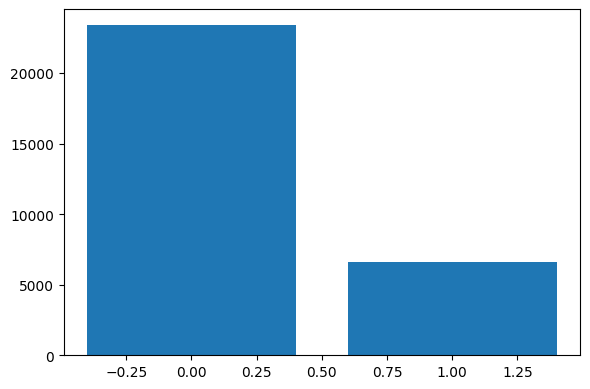

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
index = [i[0] for i in counts.index.to_list()]
ax.bar(index, counts.values)
plt.tight_layout()
plt.show()

# **Numerical Column Skew**

In [ ]:
num.describe()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [ ]:
skew_values = num.skew(numeric_only=True)
skewed_columns = skew_values[skew_values.abs() > 1].index.tolist()
skew_values

,0
LIMIT_BAL,0.992867
AGE,0.732246
BILL_AMT1,2.663861
BILL_AMT2,2.705221
BILL_AMT3,3.087830
BILL_AMT4,2.821965
BILL_AMT5,2.876380
BILL_AMT6,2.846645
PAY_AMT1,14.668364
PAY_AMT2,30.453817


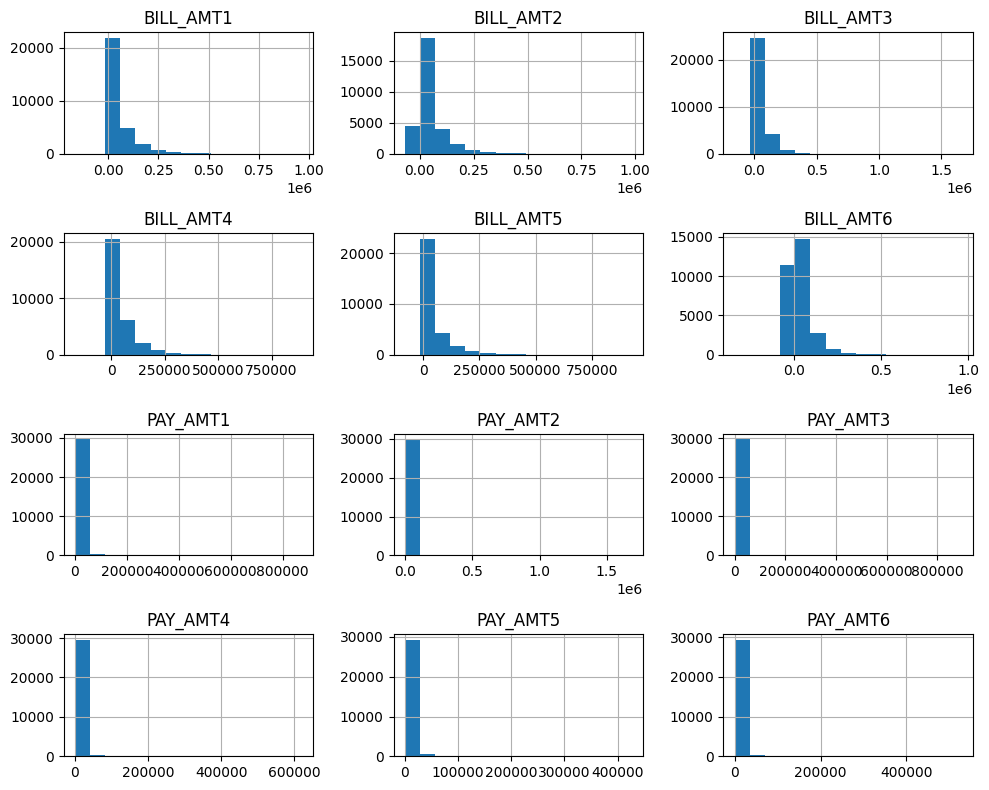

In [ ]:
X[skewed_columns].hist(bins=15, figsize=(10, 8))
plt.tight_layout()
plt.show()

All of the skewed features have positive skew, so lets try transforming it. Since some values in bill amt are negative log1p will not work. So lets use a yeo johnson transformer

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
X[skewed_columns] = pt.fit_transform(X[skewed_columns])
X[skewed_columns].skew()

,0
BILL_AMT1,-2.448036
BILL_AMT2,-1.310403
BILL_AMT3,-3.235929
BILL_AMT4,-2.821533
BILL_AMT5,-1.323215
BILL_AMT6,-3.025677
PAY_AMT1,-0.133111
PAY_AMT2,-0.112972
PAY_AMT3,-0.151916
PAY_AMT4,-0.165690


# **Numerical Outliers**

In [ ]:
Q1 = num.quantile(0.25)
Q3 = num.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier_mask = num[(num <= lower) | (num >= upper)]
outlier_count = outlier_mask.sum().sort_values(ascending=False)
outlier_count[outlier_count > 0]

,0
BILL_AMT1,597121764.0
BILL_AMT2,576049628.0
BILL_AMT3,567889202.0
BILL_AMT4,549074548.0
BILL_AMT5,531240300.0
BILL_AMT6,513494915.0
PAY_AMT2,105499553.0
PAY_AMT6,104089484.0
LIMIT_BAL,103180000.0
PAY_AMT1,95241666.0


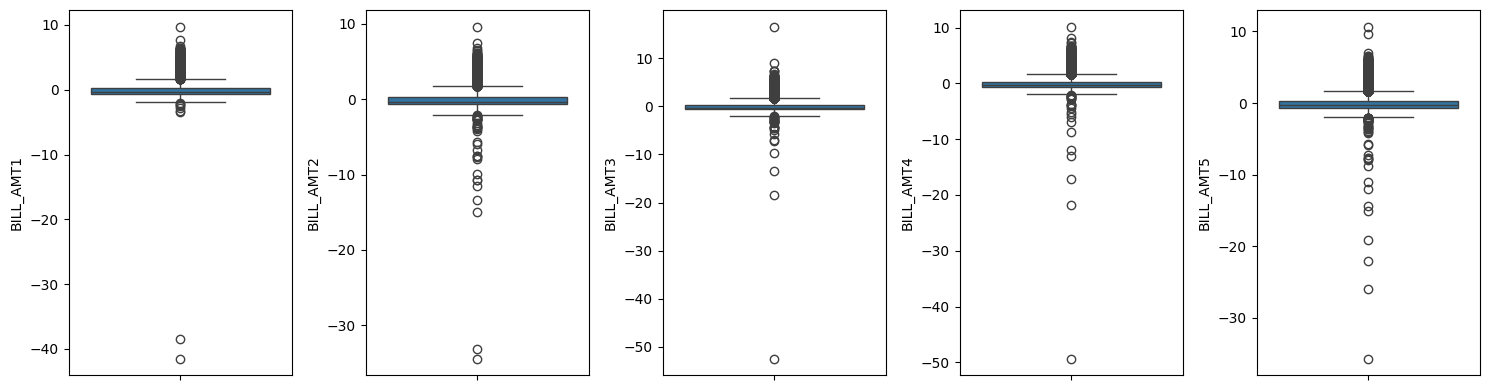

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, col in enumerate(outlier_count.head(5).index.tolist()):
  sns.boxplot(data=X, y=col, ax=axes[i])
plt.tight_layout()
plt.show()

# **Feature Correlation**

In [ ]:
corr_matrix = num.corr()
corr_matrix.head(5)

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,1.000000,0.144713,0.285430,0.278314,0.283236,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595
AGE,0.144713,1.000000,0.056239,0.054283,0.053710,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478
BILL_AMT1,0.285430,0.056239,1.000000,0.951484,0.892279,0.860272,0.829779,0.802650,0.140277,0.099355,0.156887,0.158303,0.167026,0.179341
BILL_AMT2,0.278314,0.054283,0.951484,1.000000,0.928326,0.892482,0.859778,0.831594,0.280365,0.100851,0.150718,0.147398,0.157957,0.174256
BILL_AMT3,0.283236,0.053710,0.892279,0.928326,1.000000,0.923969,0.883910,0.853320,0.244335,0.316936,0.130011,0.143405,0.179712,0.182326


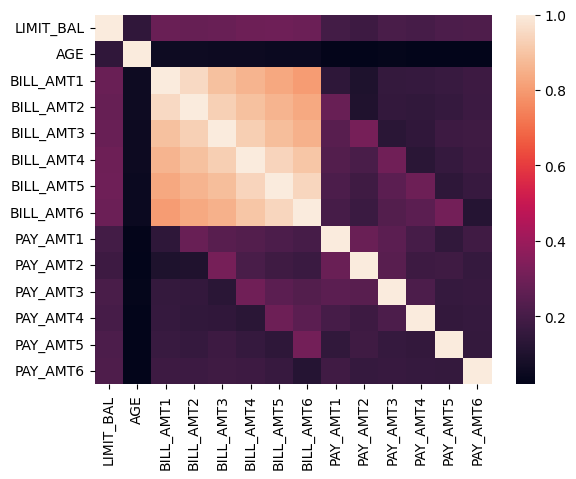

In [ ]:
sns.heatmap(corr_matrix)
plt.show()

# **Category Frequency Distribution**

In [ ]:
cat.describe()

,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,30000,30000,30000,30000,30000,30000,30000,30000,30000
unique,2,7,4,11,11,11,11,10,10
top,2,2,2,0,0,0,0,0,0
freq,18112,14030,15964,14737,15730,15764,16455,16947,16286


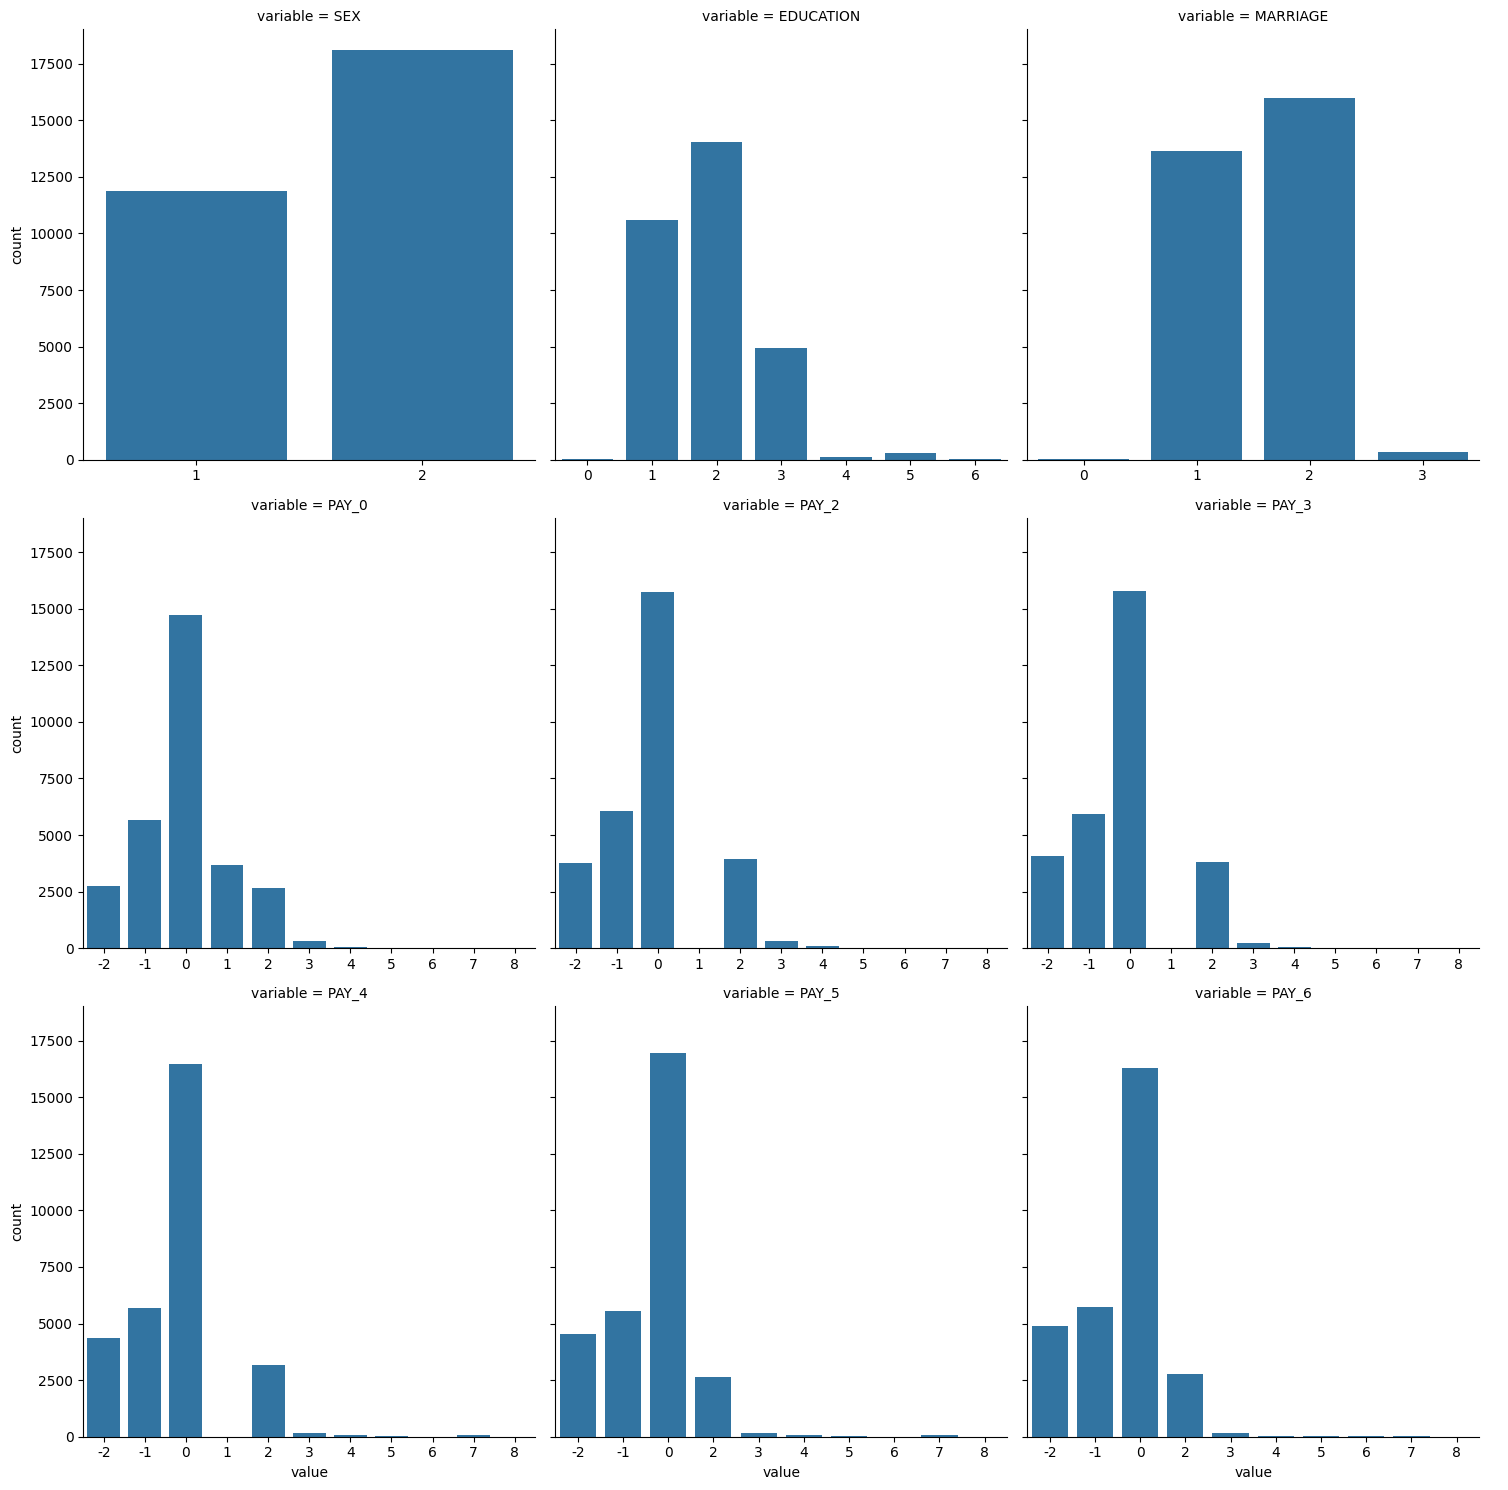

In [ ]:
melted = cat.melt()
sns.catplot(data=melted, x='value', col='variable', kind='count', col_wrap=3, sharex=False)
plt.show()

# **Target Feature Correlation**

In [ ]:
from sklearn.metrics import roc_auc_score

scores = {}
for col in num:
  score = roc_auc_score(y, num[col])
  if score < 0.5:
    score = 1 - score
  scores[col] = score
score_df = pd.DataFrame.from_dict(scores, orient="index", columns=["scores"]).sort_values(by="scores", ascending=False)
score_df

,scores
LIMIT_BAL,0.617803
PAY_AMT1,0.611317
PAY_AMT2,0.604693
PAY_AMT3,0.596555
PAY_AMT4,0.588566
PAY_AMT6,0.583877
PAY_AMT5,0.580624
BILL_AMT1,0.517612
BILL_AMT2,0.510815
BILL_AMT3,0.508808


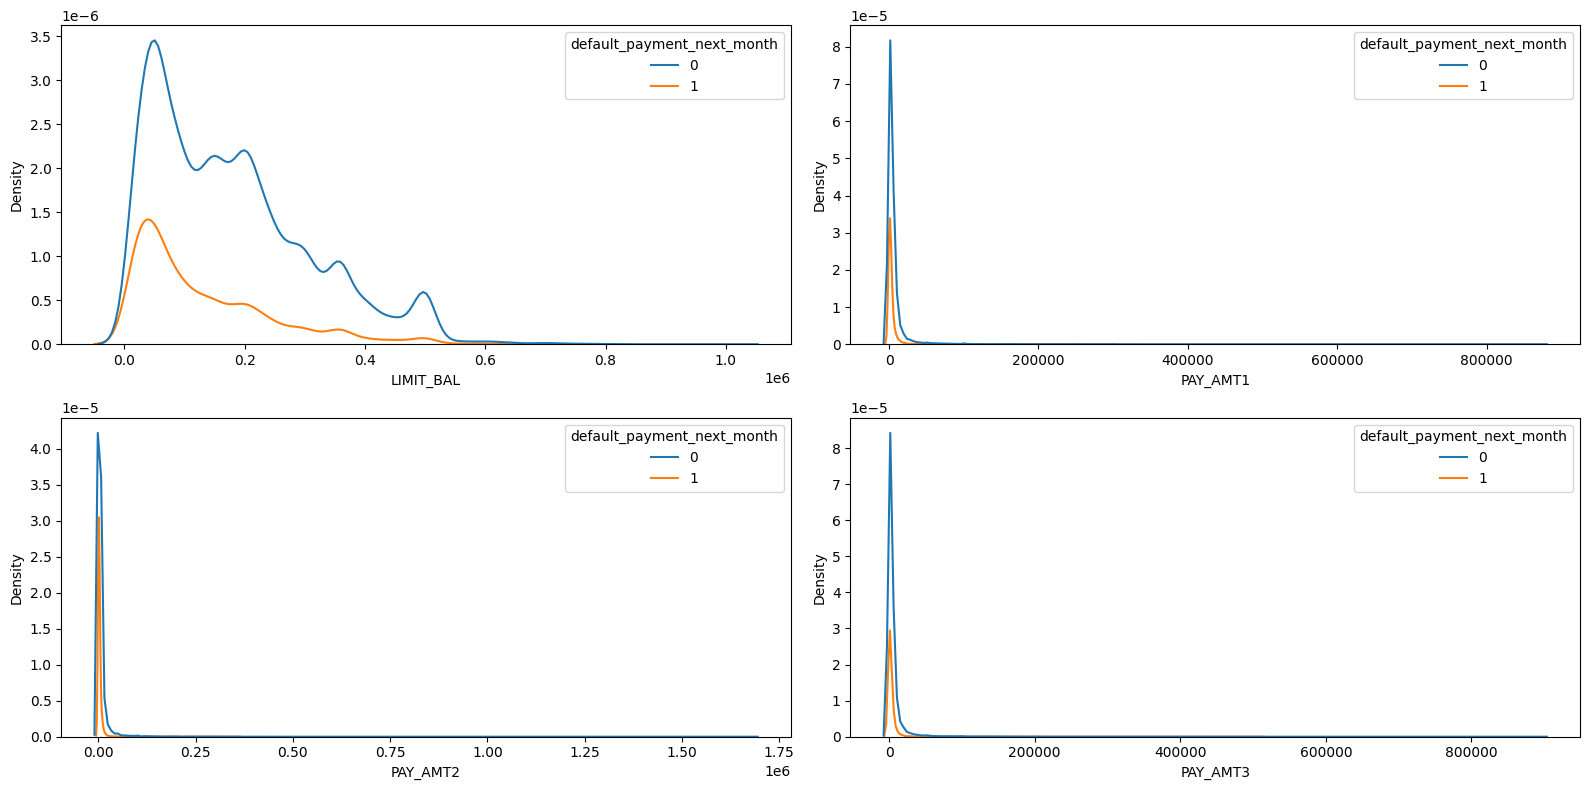

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16, 8))
ax = ax.flatten()
for i, col in enumerate(score_df.head(4).index.tolist()):
  sns.kdeplot(x=num[col], hue=y.squeeze(), ax=ax[i])
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats.contingency import association
scores = {}
for col in cat:
  ct = pd.crosstab(cat[col], y.squeeze())
  score = association(ct, method="cramer")
  scores[col] = score
scores_df = pd.DataFrame.from_dict(scores, orient="index", columns=["score"]).sort_values(by="score", ascending=False)
scores_df

,score
PAY_0,0.422925
PAY_2,0.340317
PAY_3,0.295661
PAY_4,0.279373
PAY_5,0.270659
PAY_6,0.250788
EDUCATION,0.073760
SEX,0.039961
MARRIAGE,0.034478


# **Feature Engineering**

In [ ]:
num["TOTAL_BILL"] = num["BILL_AMT1"] + num["BILL_AMT2"] + num["BILL_AMT3"] + num["BILL_AMT4"] + num["BILL_AMT5"] + num["BILL_AMT6"]
num["TOTAL_PAY"] = num["PAY_AMT1"] + num["PAY_AMT2"] + num["PAY_AMT3"] + num["PAY_AMT4"] + num["PAY_AMT5"] + num["PAY_AMT6"]
num["PAY_TO_BILL_RATIO"] = num["TOTAL_BILL"] / (num["TOTAL_PAY"] + 1)
num[["TOTAL_BILL", "TOTAL_PAY", "PAY"]]

,TOTAL_BILL
0,-4.094428
1,-3.843593
2,-2.244308
3,-0.131634
4,-2.106356
...,...
29995,6.262987
29996,-3.761104
29997,-2.790819
29998,0.083613
